In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path="/content/drive/MyDrive/healthcare_dataset.csv"

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Rows and Columns: (55500, 15)

Column Names:
Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billi

In [6]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Billing Amount'] = df['Billing Amount'].fillna(df['Billing Amount'].median())

In [8]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Medical Condition'] = df['Medical Condition'].fillna(df['Medical Condition'].mode()[0])
df['Admission Type'] = df['Admission Type'].fillna(df['Admission Type'].mode()[0])

In [9]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'],
    errors='coerce'
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date'],
    errors='coerce'
)

In [10]:
print(df[['Date of Admission', 'Discharge Date']].head())

  Date of Admission Discharge Date
0        2024-01-31     2024-02-02
1        2019-08-20     2019-08-26
2        2022-09-22     2022-10-07
3        2020-11-18     2020-12-18
4        2022-09-19     2022-10-09


In [11]:
df['Hospital Stay Days'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

In [12]:
df[['Date of Admission', 'Discharge Date', 'Hospital Stay Days']].head()

,Date of Admission,Discharge Date,Hospital Stay Days
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [13]:
df['Admission Type'] = df['Admission Type'].str.strip().str.title()

df['Urgency Category'] = df['Admission Type'].replace({
    'Emergency': 'Emergency',
    'Elective': 'Elective',
    'Urgent': 'Urgent'
})

In [14]:
print(df['Urgency Category'].value_counts())

Urgency Category
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64


In [15]:
print("Billing Amount Statistics")

print("Mean:", df['Billing Amount'].mean())
print("Median:", df['Billing Amount'].median())
print("Minimum:", df['Billing Amount'].min())
print("Maximum:", df['Billing Amount'].max())
print("Standard Deviation:", df['Billing Amount'].std())

Billing Amount Statistics
Mean: 25539.316097211795
Median: 25538.069375965664
Minimum: -2008.4921398591305
Maximum: 52764.276736469175
Standard Deviation: 14211.45443086446


In [16]:
print("Hospital Stay Statistics")

print("Mean:", df['Hospital Stay Days'].mean())
print("Median:", df['Hospital Stay Days'].median())
print("Minimum:", df['Hospital Stay Days'].min())
print("Maximum:", df['Hospital Stay Days'].max())
print("Standard Deviation:", df['Hospital Stay Days'].std())

Hospital Stay Statistics
Mean: 15.50900900900901
Median: 15.0
Minimum: 1
Maximum: 30
Standard Deviation: 8.659600186525173


In [17]:
df[['Billing Amount', 'Hospital Stay Days']].describe()

,Billing Amount,Hospital Stay Days
count,55500.000000,55500.000000
mean,25539.316097,15.509009
std,14211.454431,8.659600
min,-2008.492140,1.000000
25%,13241.224652,8.000000
50%,25538.069376,15.000000
75%,37820.508436,23.000000
max,52764.276736,30.000000


In [18]:
print(df['Medical Condition'].value_counts())

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64


In [19]:
demographic_analysis = df.groupby('Medical Condition').agg(
    Average_Age=('Age', 'mean'),
    Patient_Count=('Age', 'count')
)

print(demographic_analysis)

                   Average_Age  Patient_Count
Medical Condition                            
Arthritis            51.565320           9308
Asthma               51.575830           9185
Cancer               51.558795           9227
Diabetes             51.554170           9304
Hypertension         51.741915           9245
Obesity              51.240277           9231


In [20]:
gender_condition = pd.crosstab(
    df['Medical Condition'],
    df['Gender']
)

print(gender_condition)

Gender             Female  Male
Medical Condition              
Arthritis            4686  4622
Asthma               4553  4632
Cancer               4602  4625
Diabetes             4651  4653
Hypertension         4612  4633
Obesity              4622  4609


In [22]:
condition_billing = df.groupby('Medical Condition')['Billing Amount'].mean()
print(condition_billing)

Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64


In [23]:
condition_stay = df.groupby('Medical Condition')['Hospital Stay Days'].mean()
print(condition_stay)

Medical Condition
Arthritis       15.517404
Asthma          15.696570
Cancer          15.495827
Diabetes        15.422936
Hypertension    15.458626
Obesity         15.464305
Name: Hospital Stay Days, dtype: float64


**Simple Visualization**

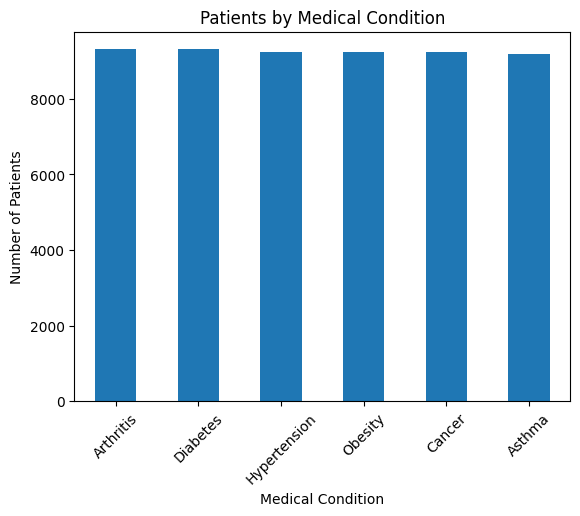

In [25]:
import matplotlib.pyplot as plt
df['Medical Condition'].value_counts().plot(kind='bar')
plt.title('Patients by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

**Billing Amount Distribution**

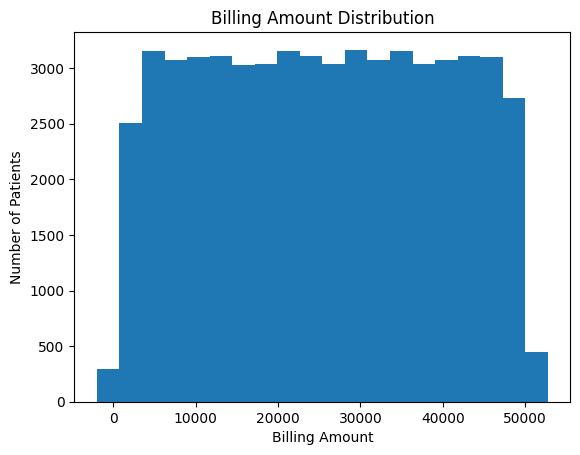

In [26]:
plt.hist(df['Billing Amount'], bins=20)
plt.title('Billing Amount Distribution')
plt.xlabel('Billing Amount')
plt.ylabel('Number of Patients')
plt.show()

**Hospital Stay Distribution**

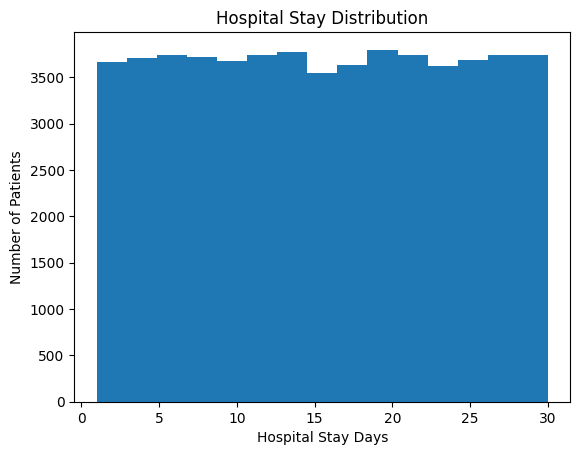

In [27]:
plt.hist(df['Hospital Stay Days'], bins=15)
plt.title('Hospital Stay Distribution')
plt.xlabel('Hospital Stay Days')
plt.ylabel('Number of Patients')
plt.show()

In [28]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Hospital Stay Days    0
Urgency Category      0
dtype: int64


In [29]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Hospital Stay Days,Urgency Category
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,Urgent
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,Emergency
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,Emergency
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,Elective
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,Urgent
